In [1]:
!pip install feast scikit-learn pandas pyarrow -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires tenacity<10.0.0,>=9.0.0, but you have tenacity 8.5.0 which is incompatible.


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ealaxi/paysim1")

print("Path to dataset files:", path)
print(os.listdir(path))

100%|██████████| 178M/178M [00:05<00:00, 32.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ealaxi/paysim1/versions/2
['PS_20174392719_1491204439457_log.csv']


In [4]:
df = pd.read_csv(os.path.join(path, 'PS_20174392719_1491204439457_log.csv'))
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.shape

(6362620, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
def check():
  A = []
  columns = df.columns

  for i in columns:
    isnull = df[i].isnull().sum()
    unique = df[i].nunique()
    dtype = df[i].dtype
    A.append([i,isnull,unique,dtype])
  dff = pd.DataFrame(A,columns=['Column','Null','Unique','Dtype'])
  return dff

check()

,Column,Null,Unique,Dtype
0,step,0,743,int64
1,type,0,5,object
2,amount,0,5316900,float64
3,nameOrig,0,6353307,object
4,oldbalanceOrg,0,1845844,float64
5,newbalanceOrig,0,2682586,float64
6,nameDest,0,2722362,object
7,oldbalanceDest,0,3614697,float64
8,newbalanceDest,0,3555499,float64
9,isFraud,0,2,int64


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


,count
type,
CASH_OUT,2237500
PAYMENT,2151495
CASH_IN,1399284
TRANSFER,532909
DEBIT,41432


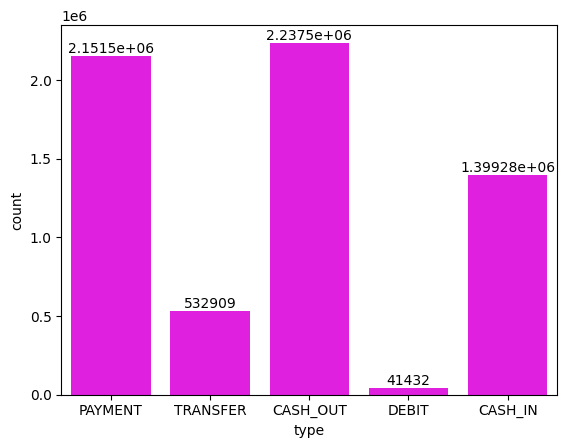

In [10]:
ax = sns.countplot(data=df, x='type',color='magenta')
ax.bar_label(ax.containers[0])

df['type'].value_counts()

<Axes: xlabel='isFraud', ylabel='amount'>

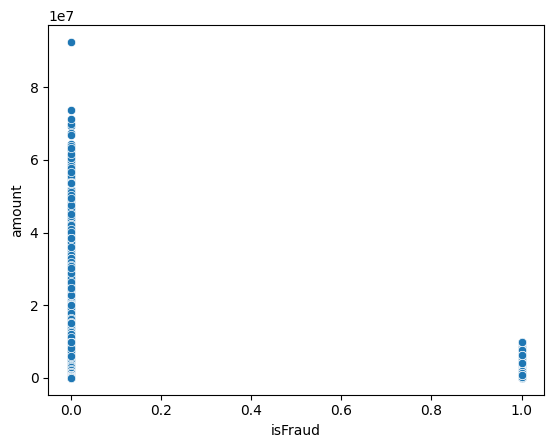

In [11]:
sns.scatterplot(data=df, x='isFraud', y='amount')

In [12]:
df[df['isFraud']==1]['amount'].describe().astype(int)

,amount
count,8213
mean,1467967
std,2404252
min,0
25%,127091
50%,441423
75%,1517771
max,10000000


In [13]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [14]:
df['customer_id'] = df['nameOrig']

#encoding
type_map = {'PAYMENT': 0, 'TRANSFER': 1, 'CASH_OUT': 2, 'DEBIT': 3, 'CASH_IN': 4}
df['type_encoded'] = df['type'].map(type_map)



In [15]:
# Balance difference
df['balance_diff'] = df['oldbalanceOrg'] - df['newbalanceOrig']

In [16]:
df['balance_diff'].mean().astype(int)

np.int64(-21230)

In [17]:
df['amount_ratio'] = df['amount'] / df['oldbalanceOrg']
df.loc[df['oldbalanceOrg'] <= 0, 'amount_ratio'] = 0

In [18]:
df['check_zero'] = (df['newbalanceOrig'] == 0).astype(int)

df['dest_balance_change'] = df['newbalanceDest'] - df['oldbalanceDest']




In [19]:
# Aggregations
agg = df.groupby('customer_id').agg(
    txn_count=('amount', 'count'),
    avg_amount=('amount', 'mean'),
    max_amount=('amount', 'max'),
    total_amount=('amount', 'sum')
).reset_index()

df = df.merge(agg, on='customer_id', how='left')

df[['customer_id', 'balance_diff', 'amount_ratio', 'check_zero',
    'type_encoded', 'txn_count', 'avg_amount', 'isFraud']].head()

,customer_id,balance_diff,amount_ratio,check_zero,type_encoded,txn_count,avg_amount,isFraud
0,C1231006815,9839.64,0.057834,0,0,1,9839.64,0
1,C1666544295,1864.28,0.087735,0,0,1,1864.28,0
2,C1305486145,181.00,1.000000,1,1,1,181.00,1
3,C840083671,181.00,1.000000,1,2,1,181.00,1
4,C2048537720,11668.14,0.280795,0,0,1,11668.14,0


In [20]:
time = datetime(2026, 1, 1)
df['event_timestamp'] = df['step'].apply(lambda x: time + timedelta(hours=x))

In [21]:
# Offline store ucun featurelar
columns = [
    'customer_id', 'event_timestamp',
    'amount', 'type_encoded',
    'balance_diff', 'amount_ratio', 'check_zero',
    'dest_balance_change',
    'txn_count', 'avg_amount', 'max_amount',
    'isFraud'
]

feature_df = df[columns].copy()

os.makedirs('feature_store/data', exist_ok=True)

feature_df.to_parquet('feature_store/data/transactions.parquet', index=False)
print(feature_df.shape)

(6362620, 12)


In [22]:
repo_code = '''
from feast import Entity, FeatureView, Field, FileSource
from feast.types import Float64, Int64, String
from datetime import timedelta

#  Entity
customer = Entity(
    name="customer_id",
    description="Bank musteri ID-si (nameOrig)"
)

# Data Source (Offline: Parquet)
transaction_source = FileSource(
    path="data/transactions.parquet",
    timestamp_field="event_timestamp",
)

# Feature View
transaction_fv = FeatureView(
    name="transaction_features",
    entities=[customer],
    ttl=timedelta(days=30),     # 30 gunden kone feature-lari istifade etme
    schema=[
        Field(name="amount",            dtype=Float64),
        Field(name="type_encoded",      dtype=Int64),
        Field(name="balance_diff",      dtype=Float64),
        Field(name="amount_ratio",      dtype=Float64),
        Field(name="check_zero",     dtype=Int64),
        Field(name="dest_balance_change", dtype=Float64),
        Field(name="txn_count",         dtype=Int64),
        Field(name="avg_amount",        dtype=Float64),
        Field(name="max_amount",        dtype=Float64),
    ],
    source=transaction_source,
)
'''

with open('feature_store/feature_repo.py', 'w') as f:
    f.write(repo_code)

# feature_store_config.yaml
yaml_code = '''
project: fraud_detection
registry: registry.db
provider: local
online_store:
  type: sqlite
  path: online_store.db
entity_key_serialization_version: 2
'''

with open('feature_store/feature_store.yaml', 'w') as f:
    f.write(yaml_code)

In [23]:
!cd feature_store && feast apply

/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:45: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'
  ParserElement.enablePackrat()
In /usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'parseString' deprecated - use 'parse_string'
In /usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'reset

## Materialization Offline/Online Store

In [24]:
from feast import FeatureStore

store = FeatureStore(repo_path='feature_store')

# Son 1 ayin featurelerini yuklemek
end = datetime.now()
start = end - timedelta(days=30)

store.materialize(start_date=start, end_date=end)

/usr/local/lib/python3.12/dist-packages/feast/repo_config.py:389: DeprecationWarning: The serialization version below 3 are deprecated. Specifying `entity_key_serialization_version` to 3 is recommended.
  warnings.warn(


Materializing 1 feature views from 2026-04-12 10:57:22+00:00 to 2026-05-12 10:57:22+00:00 into the sqlite online store.

transaction_features:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [25]:
store

FeatureStore(
    repo_path=PosixPath('feature_store'),
    config=RepoConfig(project='fraud_detection', project_description=None, provider='local', registry_config='registry.db', online_config={'type': 'sqlite', 'path': 'online_store.db'}, auth={'type': 'no_auth'}, offline_config='dask', batch_engine_config='local', feature_server=None, flags=None, repo_path=PosixPath('feature_store'), entity_key_serialization_version=2, coerce_tz_aware=True, materialization_config=MaterializationConfig(pull_latest_features=False, online_write_batch_size=None), openlineage_config=None),
    registry=loaded,
    provider=loaded
)

In [26]:
fraud = feature_df[feature_df['isFraud'] == 1]
nonfraud = feature_df[feature_df['isFraud'] == 0]

n_fraud = len(fraud)
n_nonfraud = 500000 - n_fraud

nonfraud_sample = nonfraud.sample(n=n_nonfraud, random_state=42)

# Birləşdirmek
entity_df = pd.concat([fraud, nonfraud])

# Qarışdır
entity_df = entity_df.sample(frac=1, random_state=42)

entity_df = entity_df[['customer_id', 'event_timestamp', 'isFraud']]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [37]:
eentity_df =entity_df.sort_values(by='event_timestamp', ascending=True)

In [38]:
entity_df['isFraud'].value_counts()

,count
isFraud,
0,491787
1,8213


In [39]:
training_data = store.get_historical_features(
    entity_df=entity_df,
    features=[
        'transaction_features:amount',
        'transaction_features:type_encoded',
        'transaction_features:balance_diff',
        'transaction_features:amount_ratio',
        'transaction_features:check_zero',
        'transaction_features:txn_count',
        'transaction_features:avg_amount',
        'transaction_features:max_amount',
    ]
).to_df()

print('Training dataset shape:', training_data.shape)
print('Fraud ratio:', training_data['isFraud'].mean().round(4))
training_data.head()

Training dataset shape: (500000, 11)
Fraud ratio: 0.0164


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,customer_id,event_timestamp,isFraud,amount,type_encoded,balance_diff,amount_ratio,check_zero,txn_count,avg_amount,max_amount
0,C1231006815,2026-01-01 01:00:00+00:00,0,9839.64,0,9839.64,0.057834,0,1,9839.64,9839.64
1,C215478702,2026-01-01 01:00:00+00:00,0,151764.65,4,-151764.65,0.039711,0,1,151764.65,151764.65
2,C1401737458,2026-01-01 01:00:00+00:00,0,65525.90,4,-65525.90,0.010691,0,1,65525.90,65525.90
3,C1871312485,2026-01-01 01:00:00+00:00,0,5567.55,0,870.00,6.399483,1,1,5567.55,5567.55
4,C1227224309,2026-01-01 01:00:00+00:00,0,4213.36,0,4213.36,0.018035,0,1,4213.36,4213.36


In [40]:
entity_df['isFraud'].value_counts()

,count
isFraud,
0,491787
1,8213


In [41]:
features = [
    'amount', 'type_encoded', 'balance_diff',
    'amount_ratio', 'check_zero',
    'txn_count', 'avg_amount', 'max_amount'
]
split = int(len(training_data) * 0.8)

train_df = training_data.dropna(subset=features)
train = train_df.iloc[:split]
test  = train_df.iloc[split:]

X_train = train[features]
y_train = train['isFraud']

X_test = test[features]
y_test = test['isFraud']

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [43]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     95752
           1       1.00      1.00      1.00      4248

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [44]:
y_prob

array([0., 0., 0., ..., 1., 1., 1.])